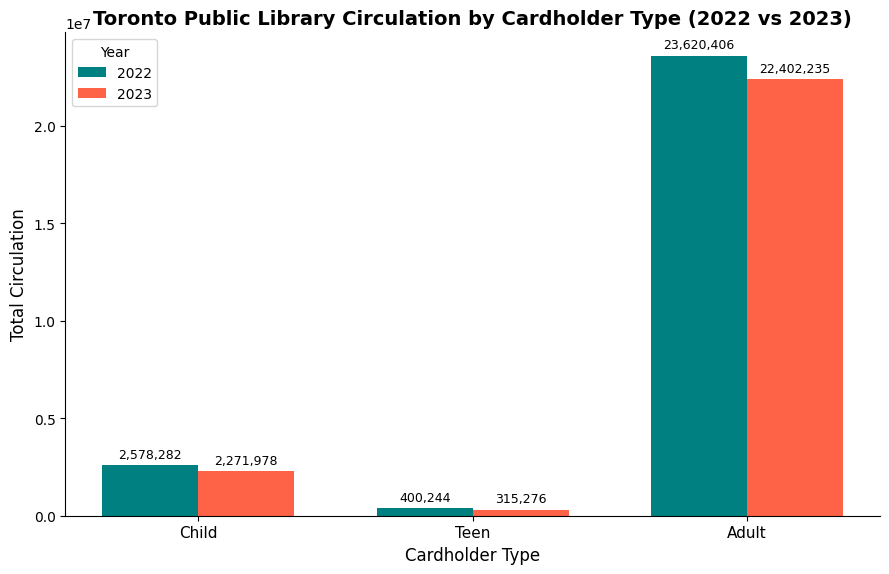

In [2]:
"""
Assignment 3: Final Project - Visualization 1 (Python)
Dataset: Library Circulation by Cardholder Type (Toronto Public Library)
Source: https://open.toronto.ca/dataset/library-circulation-by-cardholder-type/

This script creates a grouped bar chart comparing total library circulation
by cardholder type (Child, Teen, Adult) across 2022 and 2023.
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Step 1: Load and inspect data
# -----------------------------
df = pd.read_csv("library-circulation-by-cardholder-type.csv")

# -----------------------------
# Step 2: Aggregate data
# We sum circulation across all branches, grouped by Year and CardholderType
# -----------------------------
summary = df.groupby(['Year', 'CardholderType'])['Circulation'].sum().reset_index()

# Pivot for easier plotting: rows = CardholderType, columns = Year
pivot = summary.pivot(index='CardholderType', columns='Year', values='Circulation')

# Reorder cardholder types logically (Child -> Teen -> Adult)
pivot = pivot.reindex(['Child', 'Teen', 'Adult'])

# -----------------------------
# Step 3: Create the visualization
# Design considerations:
# - Clear axis labels and title
# - Data labels on bars for precise reading (accessibility)
# - High contrast and readable font sizes
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

x = np.arange(len(pivot.index))
width = 0.35

colors = ['teal', 'tomato']  

bars_2022 = ax.bar(x - width/2, pivot[2022], width, label='2022', color=colors[0])
bars_2023 = ax.bar(x + width/2, pivot[2023], width, label='2023', color=colors[1])

# Add data labels on top of bars for accessibility/precision
ax.bar_label(bars_2022, fmt='{:,.0f}', padding=3, fontsize=9)
ax.bar_label(bars_2023, fmt='{:,.0f}', padding=3, fontsize=9)

# Titles and labels
ax.set_title('Toronto Public Library Circulation by Cardholder Type (2022 vs 2023)',
              fontsize=14, fontweight='bold')
ax.set_xlabel('Cardholder Type', fontsize=12)
ax.set_ylabel('Total Circulation', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, fontsize=11)
ax.legend(title='Year', fontsize=10)

# Remove top/right spines for a cleaner look 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# -----------------------------
# Step 4: Save high-resolution output for submission
# -----------------------------
plt.savefig('visualization_1_python.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# -----------------------------
# Prepare data subset for Visualization 2 (Excel)
# Top 15 branches by total circulation in 2023
# -----------------------------
top15 = (df[df['Year'] == 2023]
         .groupby('BranchCode')['Circulation']
         .sum()
         .sort_values(ascending=False)
         .head(15)
         .reset_index())

top15.to_csv('top15_branches_2023.csv', index=False)
print(top15)

   BranchCode  Circulation
0         VIR     12313520
1          CL       616108
2          FV       325661
3          AG       309927
4          RI       306733
5          BF       289654
6          BR       281541
7          DM       279003
8          ND       269831
9          EA       268145
10        SWS       247483
11         LE       235300
12         RN       233294
13         BL       227089
14         PA       212393
